In [1]:
import nltk
from os import getcwd

In [3]:
# pip install concrete-ml

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
import numpy as np
import pandas as pd

In [5]:
train_df= pd.read_csv('PubMed_20k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_20k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_20k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24293578,24293578_0_12,To investigate the efficacy of 6 weeks of dail...,0,12,OBJECTIVE
1,24293578,24293578_1_12,A total of 125 patients with primary knee OA w...,1,12,METHODS
2,24293578,24293578_2_12,Outcome measures included pain reduction and i...,2,12,METHODS
3,24293578,24293578_3_12,Pain was assessed using the visual analog pain...,3,12,METHODS
4,24293578,24293578_4_12,Secondary outcome measures included the Wester...,4,12,METHODS


In [6]:
print(train_df.describe())
print(train_df.info())

        abstract_id    line_number    total_lines
count  1.800400e+05  180040.000000  180040.000000
mean   2.501496e+07       5.894568      12.789136
std    5.153296e+05       4.127672       3.236095
min    2.421977e+07       0.000000       4.000000
25%    2.458516e+07       3.000000      11.000000
50%    2.495697e+07       6.000000      12.000000
75%    2.539212e+07       9.000000      15.000000
max    2.652916e+07      30.000000      31.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180040 entries, 0 to 180039
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   abstract_id    180040 non-null  int64 
 1   line_id        180040 non-null  object
 2   abstract_text  180040 non-null  object
 3   line_number    180040 non-null  int64 
 4   total_lines    180040 non-null  int64 
 5   target         180040 non-null  object
dtypes: int64(3), object(3)
memory usage: 8.2+ MB
None


In [1]:
print(dev_df.describe())
print(dev_df.info())

NameError: name 'dev_df' is not defined

In [8]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  3.013500e+04  30135.000000  30135.000000
mean   2.504292e+07      5.922980     12.845960
std    5.209988e+05      4.141561      3.232885
min    2.422001e+07      0.000000      4.000000
25%    2.461834e+07      3.000000     11.000000
50%    2.500021e+07      6.000000     12.000000
75%    2.542062e+07      9.000000     15.000000
max    2.652158e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30135 entries, 0 to 30134
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30135 non-null  int64 
 1   line_id        30135 non-null  object
 2   abstract_text  30135 non-null  object
 3   line_number    30135 non-null  int64 
 4   total_lines    30135 non-null  int64 
 5   target         30135 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [9]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
dev_df.head()

,abstract_text,line_number,total_lines,target
0,IgE sensitization to Aspergillus fumigatus and...,0,10,BACKGROUND
1,It is not clear whether these patients would b...,1,10,BACKGROUND
2,We sought to determine whether a 3-month cours...,2,10,OBJECTIVE
3,Asthmatic patients who were IgE sensitized to ...,3,10,METHODS
4,Primary outcomes were improvement in quality o...,4,10,METHODS


In [10]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

def process_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    
    return tokens

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    tokenizer=process_text,
    ngram_range=(1,2),
    max_features=50000
)

X_train_text = vectorizer.fit_transform(train_df['abstract_text'])
X_dev_text   = vectorizer.transform(dev_df['abstract_text'])

C:\Users\Shyam\Cryptomedbench\tf_env\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [13]:
train_rel_pos = (
    train_df['line_number'] / train_df['total_lines']
).values.reshape(-1, 1)

dev_rel_pos = ( 
    dev_df['line_number']/ dev_df['total_lines']
).values.reshape(-1,1)

In [14]:
train_line = train_df['line_number'].values.reshape(-1, 1)
dev_line   = dev_df['line_number'].values.reshape(-1, 1)

In [15]:
from scipy.sparse import hstack
X_train = hstack([X_train_text, train_rel_pos, train_line])
X_dev   = hstack([X_dev_text, dev_rel_pos, dev_line])

In [16]:
print(X_train)

<COOrdinate sparse matrix of dtype 'float64'
	with 3291306 stored elements and shape (180040, 50002)>
  Coords	Values
  (0, 22660)	0.1159610804069701
  (0, 13215)	0.08940363423818512
  (0, 48984)	0.174528976397341
  (0, 9852)	0.10163351560881044
  (0, 24765)	0.1944768074089593
  (0, 12118)	0.09363985042827397
  (0, 29922)	0.10792566618186004
  (0, 34117)	0.1633413354992431
  (0, 20763)	0.1263479071395728
  (0, 30524)	0.08891632249711864
  (0, 27070)	0.1507505633645565
  (0, 43868)	0.1306784510813318
  (0, 17609)	0.12322307086200568
  (0, 21561)	0.1294054369576211
  (0, 40353)	0.11655208468217877
  (0, 44320)	0.10609270276448064
  (0, 49229)	0.10319404984211597
  (0, 12838)	0.08863601716113195
  (0, 49644)	0.12493507969433426
  (0, 43575)	0.13356923742295637
  (0, 29588)	0.11794624000508185
  (0, 1045)	0.11128989145608369
  (0, 27136)	0.11274387777280621
  (0, 40120)	0.11118921562983435
  (0, 23286)	0.12723165117296947
  :	:
  (180013, 50001)	7.0
  (180014, 50001)	8.0
  (180015, 50001)	

In [17]:
y_train = train_df['target']
y_dev = dev_df['target']

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_dev_enc   = label_encoder.transform(y_dev)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=1   # ← FIX
)

model.fit(X_train, y_train_enc)

C:\Users\Shyam\Cryptomedbench\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
from sklearn.metrics import classification_report

y_dev_pred = model.predict(X_dev)

print(classification_report(
    y_dev_enc,
    y_dev_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

  BACKGROUND       0.68      0.69      0.68      3449
 CONCLUSIONS       0.86      0.93      0.90      4582
     METHODS       0.91      0.90      0.90      9964
   OBJECTIVE       0.62      0.69      0.65      2376
     RESULTS       0.92      0.87      0.89      9841

    accuracy                           0.85     30212
   macro avg       0.80      0.82      0.81     30212
weighted avg       0.86      0.85      0.85     30212



In [21]:
from scipy.sparse import vstack

X_final = vstack([X_train, X_dev])
y_final = np.concatenate([y_train_enc, y_dev_enc])

model.fit(X_final, y_final)

C:\Users\Shyam\Cryptomedbench\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
from scipy.sparse import hstack

# TF-IDF features
X_test_text = vectorizer.transform(test_df['abstract_text'])

# Position feature
test_rel_pos = (
    test_df['line_number'] / test_df['total_lines']
).values.reshape(-1, 1)

# Final test feature matrix
test_line   = test_df['line_number'].values.reshape(-1, 1)
X_test = hstack([X_test_text, test_rel_pos, test_line])

In [23]:
y_test = test_df['target']
y_test_enc = label_encoder.transform(y_test)

In [24]:
y_test_pred_enc = model.predict(X_test)

In [25]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Full per-class report
print(classification_report(
    y_test_enc,
    y_test_pred_enc,
    target_names=label_encoder.classes_,
    digits=4
))

# Accuracy
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_enc))

# Macro metrics (PRIMARY for PubMed RCT)
print("Macro Precision:", precision_score(y_test_enc, y_test_pred_enc, average='macro'))
print("Macro Recall:", recall_score(y_test_enc, y_test_pred_enc, average='macro'))
print("Macro F1:", f1_score(y_test_enc, y_test_pred_enc, average='macro'))

# Weighted metrics (SECONDARY)
print("Weighted F1:", f1_score(y_test_enc, y_test_pred_enc, average='weighted'))

              precision    recall  f1-score   support

  BACKGROUND     0.6864    0.6962    0.6913      3621
 CONCLUSIONS     0.8682    0.9309    0.8984      4571
     METHODS     0.9089    0.8979    0.9034      9897
   OBJECTIVE     0.6049    0.6725    0.6369      2333
     RESULTS     0.9208    0.8711    0.8952      9713

    accuracy                         0.8526     30135
   macro avg     0.7978    0.8137    0.8050     30135
weighted avg     0.8563    0.8526    0.8539     30135

Accuracy: 0.8525966484154638
Macro Precision: 0.7978118725287601
Macro Recall: 0.8137318280629964
Macro F1: 0.805043681960137
Weighted F1: 0.8538900394817368


In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

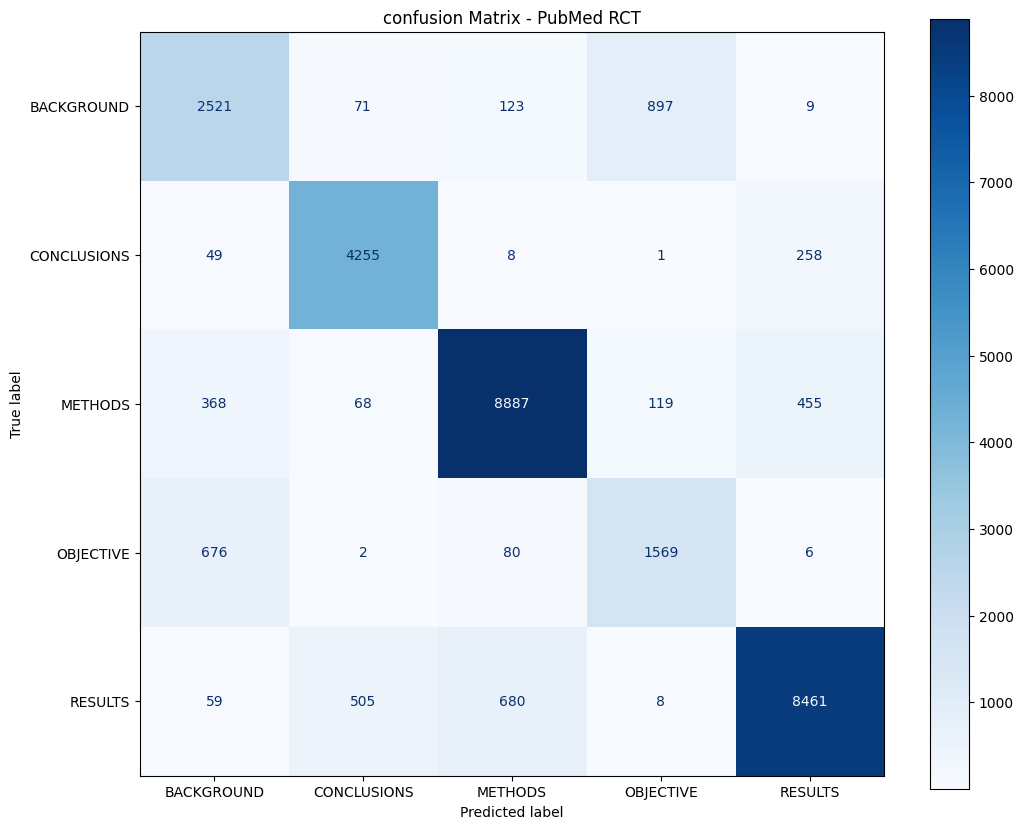

In [36]:
cm = confusion_matrix(y_test_enc, y_test_pred_enc)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = label_encoder.classes_)
fig, ax = plt.subplots(figsize = (12,10))
disp.plot(ax = ax, cmap='Blues', values_format='d')
plt.title("confusion Matrix - PubMed RCT")
plt.show()

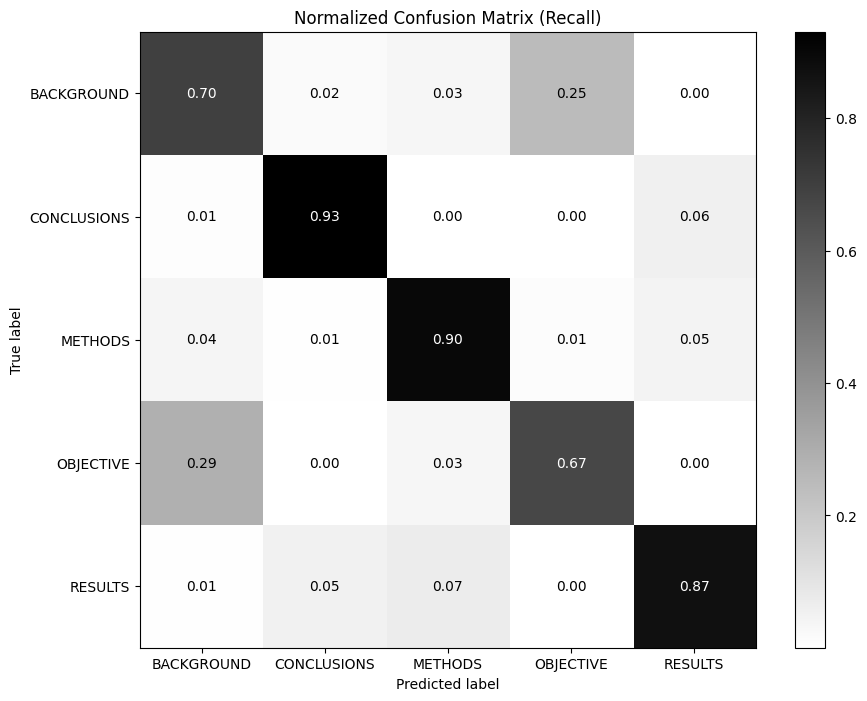

In [38]:
cm_norm = confusion_matrix(
    y_test_enc,
    y_test_pred_enc,
    normalize = 'true')

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm_norm,
    display_labels = label_encoder.classes_)

fig, ax = plt.subplots(figsize= (10,8))
disp.plot(ax = ax, cmap= 'binary', values_format = '.2f')
plt.title("Normalized Confusion Matrix (Recall)")
plt.show()

In [39]:
y_test_proba = model.predict_proba(X_test)

In [40]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize( y_test_enc,
                             classes = np.arange(len(label_encoder.classes_)))

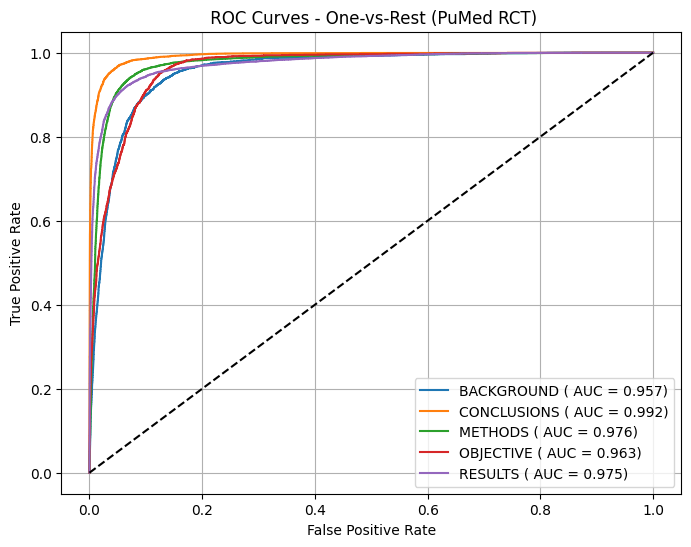

In [43]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8,6))
for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve( y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label = f"{class_name} ( AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(" ROC Curves - One-vs-Rest (PuMed RCT)")
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

In [47]:
from sklearn.metrics import roc_auc_score
macro_auc = roc_auc_score(
    y_test_bin,
    y_test_proba,
    average = 'macro',
    multi_class = 'ovr')
weighted_auc = roc_auc_score(
    y_test_bin,
    y_test_proba,
    average = 'weighted', 
    multi_class = 'ovr')
print("Macro ROC-AUC:", macro_auc)
print("Weighted ROC-AUC:", weighted_auc)

Macro ROC-AUC: 0.9725821393756504
Weighted ROC-AUC: 0.9746833481021057


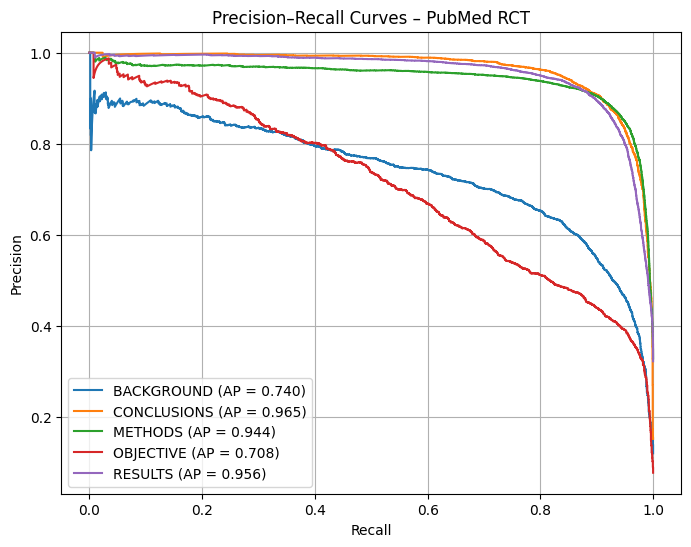

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(label_encoder.classes_):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_test_proba[:, i]
    )
    ap = average_precision_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(recall, precision, label=f"{class_name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves – PubMed RCT")
plt.legend()
plt.grid(True)
plt.show()


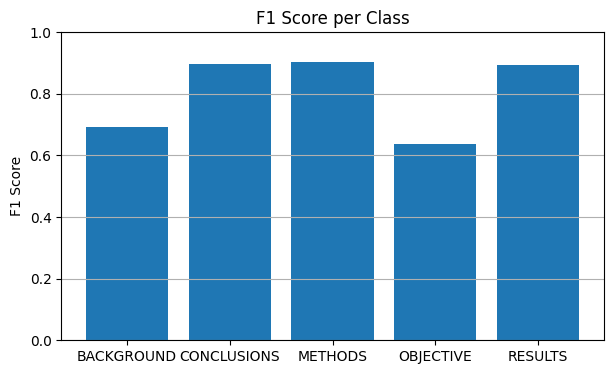

In [49]:
from sklearn.metrics import f1_score

f1_per_class = f1_score(
    y_test_enc,
    y_test_pred_enc,
    average=None
)

plt.figure(figsize=(7, 4))
plt.bar(label_encoder.classes_, f1_per_class)
plt.title("F1 Score per Class")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()
